In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Store data analysis.csv" , encoding = 'latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df.columns 

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.shape

(9800, 18)

Had a Overall View Of Our Dataset 

In [3]:
import sqlite3

conn = sqlite3.connect("superstore.db")

df.to_sql("orders", conn, if_exists="replace", index=False)

9800

In [9]:
pd.read_sql("SELECT * FROM orders LIMIT 5", conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
query1 = """
SELECT Category, SUM(Sales) as total_sales
FROM orders
GROUP BY Category
"""

cat_sales = pd.read_sql(query1, conn)
cat_sales

,Category,total_sales
0,Furniture,728658.5757
1,Office Supplies,705422.3340
2,Technology,827455.8730


Technology category generates the highest revenue, showing that customers prefer tech-related products over Furniture and Office Supplies.

In [12]:

query2 = """
select region , sum(sales) as total_sales 
from orders 
GROUP BY region 
"""
reg_sales = pd.read_sql(query2, conn)
reg_sales

,Region,total_sales
0,Central,492646.9132
1,East,669518.7260
2,South,389151.4590
3,West,710219.6845


The West region contributes the highest sales, indicating strong demand and customer presence, while other regions show comparatively lower performance.

In [14]:
query3 = """
select state , sum(sales) as total_sales 
from orders 
GROUP BY state
limit 10
"""
state_sales = pd.read_sql(query3, conn)
state_sales

,State,total_sales
0,Alabama,19510.6400
1,Arizona,35272.6570
2,Arkansas,11678.1300
3,California,446306.4635
4,Colorado,31841.5980
5,Connecticut,13384.3570
6,Delaware,27322.9990
7,District of Columbia,2865.0200
8,Florida,88436.5320
9,Georgia,48219.1100


Sales are highly concentrated in top-performing states like California and florida , suggesting strong market presence in these regions.

In [16]:
query4  = """
select segment , sum(sales) as total_sales 
from orders 
GROUP BY segment

"""
seg_sales = pd.read_sql(query4, conn)
seg_sales

,Segment,total_sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


The Consumer segment contributes the most to total sales, indicating that individual buyers are the primary revenue drivers compared to Corporate and Home Office segments.

In [20]:
query5 = """
SELECT "Product Name", SUM(Sales) AS total_sales
FROM orders
GROUP BY "Product Name"
ORDER BY total_sales DESC
LIMIT 10
"""

top_products = pd.read_sql(query5, conn)
top_products

,Product Name,total_sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


These are the top 10 products Which generates more sales and Canon imageCLASS 2200 Advanced Copier generates the highest Sales 

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
df['Postal Code'] = df['Postal Code'].fillna(0)

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

Missing values were identified in the Postal Code column and handled by filling them with 0.
- No duplicate records were found in the dataset.
- Date columns were converted to datetime format for time-based analysis.

In [ ]:
# Data Visualisation

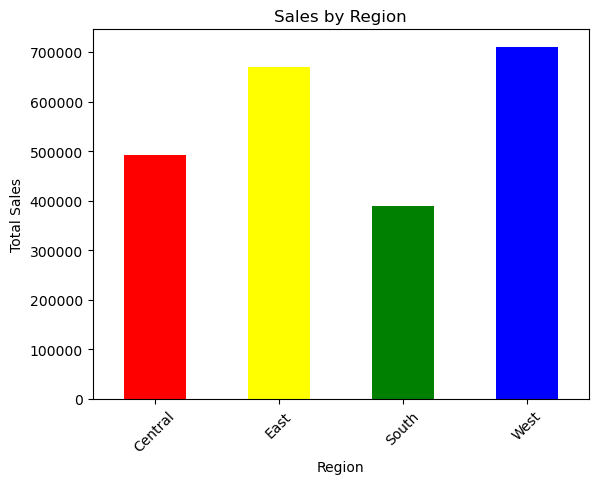

In [16]:
sales_region = df.groupby('Region')['Sales'].sum()

sales_region.plot(kind='bar', color = ['red', 'yellow','green','blue'])


plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation = 45)
plt.show()
   


### Insight:
Sales are highest in the West region, indicating a strong customer base and market demand in this area. Other regions contribute comparatively less, suggesting opportunities for business expansion.

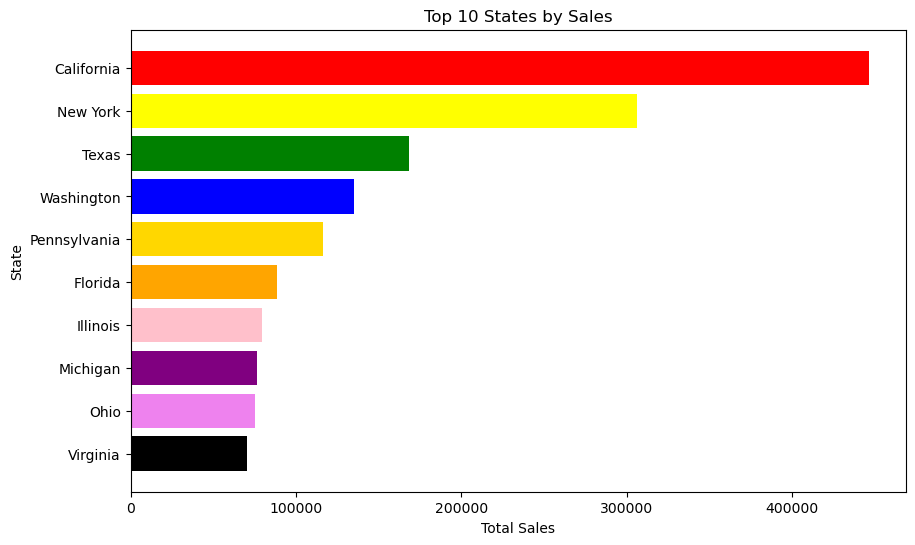

In [24]:
sales_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(sales_state.index, sales_state.values , color = ['red', 'yellow','green','blue','gold','orange','pink','purple','violet','black'])

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.gca().invert_yaxis()  # highest at top

plt.show()

   

### Insight:
Sales are concentrated in a few top-performing states such as California and New York, indicating regional dominance and higher demand in these areas.

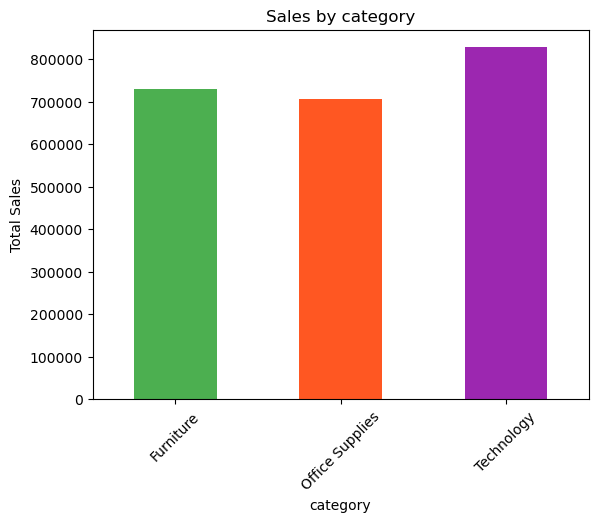

In [10]:
sales_category = df.groupby('Category')['Sales'].sum()

sales_category.plot(kind='bar', color = ['#4CAF50','#FF5722','#9C27B0'])


plt.title("Sales by category")
plt.xlabel("category")
plt.ylabel("Total Sales")

plt.xticks(rotation = 45)
plt.show()
   


### Insight:
The Technology category generates the highest revenue, followed by Furniture and Office Supplies. This indicates a strong customer preference for technology-related products.

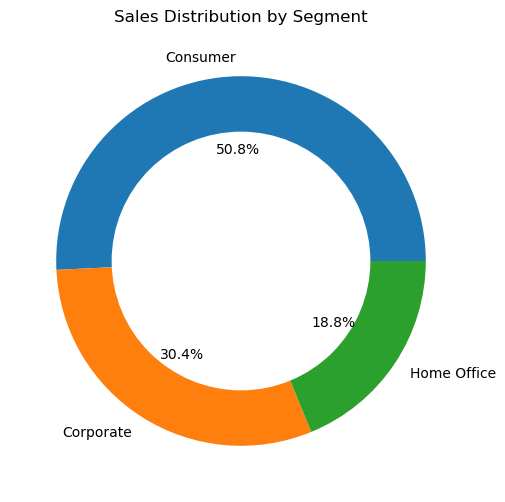

In [30]:
sales_segment = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    sales_segment,
    labels=sales_segment.index,
    autopct='%1.1f%%'
)

# Donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Sales Distribution by Segment")

plt.show()

### Insight:
The Consumer segment contributes the largest share of total sales, showing that individual customers are the primary drivers of revenue compared to Corporate and Home Office segments.

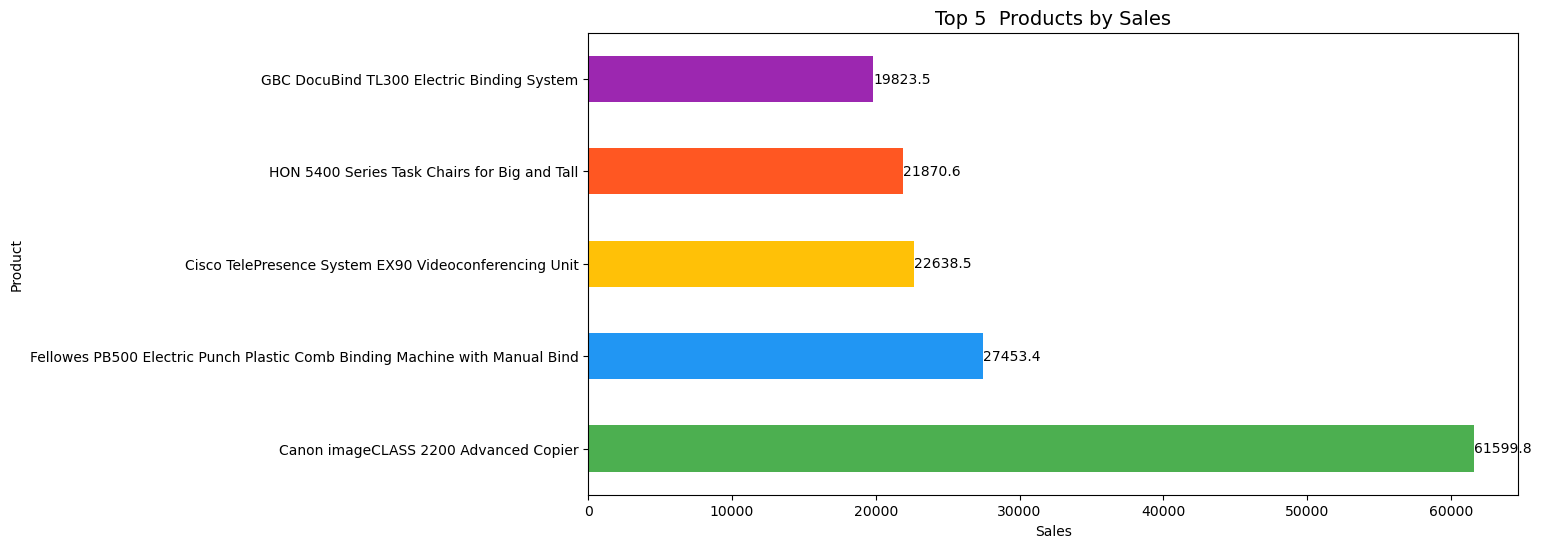

In [9]:
sales_product = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(12,6))

ax = sales_product.plot(kind='barh',color = ['#4CAF50','#2196F3','#FFC107','#FF5722','#9C27B0'])

for conatiner in ax.containers:
    ax.bar_label(conatiner)
 
plt.title("Top 5  Products by Sales",fontsize = 14)
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

### Insight:
A small number of products contribute significantly to overall sales, with the top product generating much higher revenue than others. This suggests a strong dependency on key high-performing products.

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Month'] = df['Order Date'].dt.to_period('M')

In [20]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040
2018-

In [21]:
monthly_sales.index = monthly_sales.index.astype(str)

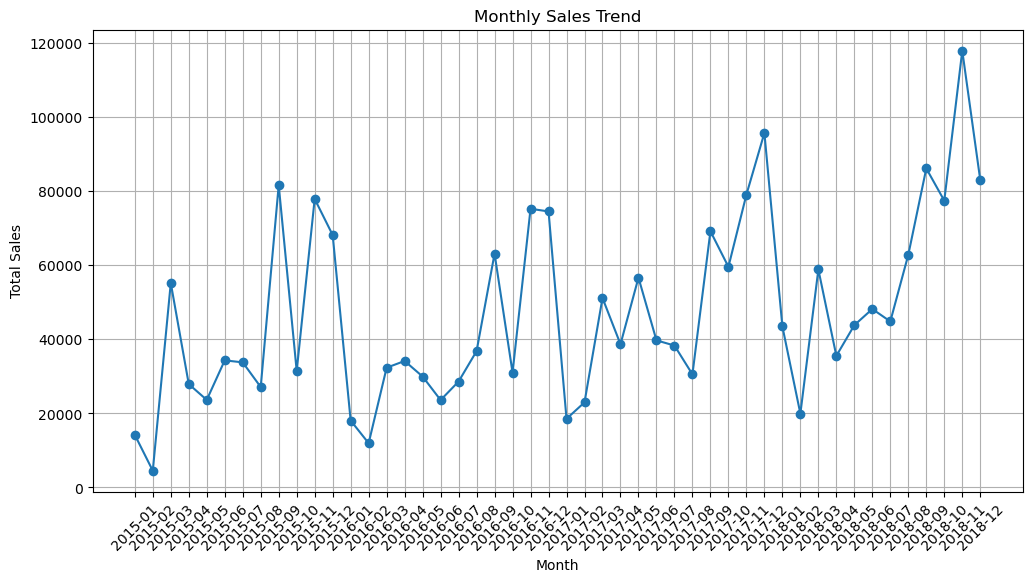

In [23]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid()

plt.show()

### Insight:
The monthly sales trend shows consistent growth over time, with peak sales occurring during the end-of-year months (September to December), especially in November. This indicates strong seasonal demand during festive periods, while the beginning of the year shows relatively lower sales.

## Final Conclusion

The analysis reveals that sales are driven primarily by the Technology category, Consumer segment, and key regions like the West. A small number of top-performing products contribute significantly to overall revenue. Additionally, sales exhibit strong seasonal trends, with peak performance during the end-of-year festive period. Businesses can focus on high-demand products, target key regions, and leverage seasonal trends to maximize revenue and growth.